# Рубежный контроль 1 · **вариант 8**

**Группа:** ИУ5-65Б *(позиция в списке = 8 → вариант 8).*

**Доп. требование для ИУ5-65Б:** построить **парные диаграммы** (*pair plot*) для набора данных.

**Задача 1.** Корреляционный анализ; при пропусках — удалить строки или столбцы с пропусками; выводы о пригодности данных для моделей машинного обучения и о вкладе признаков.

**Датасет:** Boston Housing Dataset ([Kaggle: altavish/boston-housing-dataset](https://www.kaggle.com/datasets/altavish/boston-housing-dataset)).


## 1. Загрузка данных

Сначала пробуем загрузку через **kagglehub** (если Kaggle уже настроен). Иначе — резервная ссылка на CSV (структура как у классического Boston Housing: 13 признаков + `MEDV`).


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = None
try:
    import kagglehub
    folder = Path(kagglehub.dataset_download("altavish/boston-housing-dataset"))
    csvs = sorted(folder.glob("*.csv"))
    if not csvs:
        csvs = sorted(folder.rglob("*.csv"))
    df = pd.read_csv(csvs[0])
    print(f"Загружено из kagglehub: {csvs[0].name}")
except Exception as e1:
    print("kagglehub:", e1)
    urls = [
        "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv",
        "https://gist.githubusercontent.com/nguyen-toan/867bb45c87d6bcf3bdc8eae9e14f0636/raw/"
        "BostonHousing/BostonHousing.csv",
    ]
    for url in urls:
        try:
            df = pd.read_csv(url)
            print("Загружено по URL:", url)
            break
        except Exception as e2:
            print("URL failed:", url[:60], "...", repr(e2))
    if df is None:
        raise SystemExit(
            "Не удалось загрузить данные. Установите kagglehub или скачайте CSV с Kaggle вручную в папку с ноутбуком."
        )

# Имена столбцов в едином регистре (в выгрузках Kaggle/GitHub часто lower case)
df.columns = [str(c).upper() for c in df.columns]
if "MEDV" not in df.columns:
    raise ValueError("Не найден целевой столбец MEDV — проверьте CSV.")
print("Столбцы:", list(df.columns))
print(df.shape)
df.head()


kagglehub: No module named 'kagglehub'
Загружено по URL: https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv
Столбцы: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
(506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## 2. Приведение к числовому виду и искусственные пропуски

По **примечанию к РК:** если пропусков нет, часть значений можно заменить на `NaN` для демонстрации шага очистки. Здесь случайно «обнуляем» ~6% ячеек в столбцах **`AGE`** и **`RM`**.


In [2]:
FEATURES_ORIG = df.copy()

# Дополнительный категориальный признак (по примеру из методички)
# RAD — индекс доступности магистралей → «зона»: низкая / высокая
if "RAD" in df.columns:
    df["_rad_zone"] = np.where(df["RAD"].astype(float) <= df["RAD"].astype(float).median(), "Низкая", "Высокая")
else:
    df["_rad_zone"] = "Неизвестно"

rng = np.random.default_rng(8)  # вариант 8 — фиксированный seed
for col in ["AGE", "RM"]:
    if col not in df.columns:
        continue
    vc = df[col].astype(float).copy()
    mask = rng.random(len(df)) < 0.06
    vc.loc[mask] = np.nan
    df[col] = vc

print("Пропуски до удаления строк:")
print(df.isna().sum().sort_values(ascending=False))
print("\nСтрок до:", len(df))

# Задача: удалить строки или столбцы с пропусками — удаляем **строки**
df_clean = df.dropna(axis=0, how="any").copy()
removed = len(df) - len(df_clean)
print("Удалено строк с NaN:", removed, "| Осталось:", len(df_clean))


Пропуски до удаления строк:
RM           33
AGE          27
CRIM          0
INDUS         0
ZN            0
NOX           0
CHAS          0
DIS           0
RAD           0
TAX           0
PTRATIO       0
B             0
LSTAT         0
MEDV          0
_rad_zone     0
dtype: int64

Строк до: 506
Удалено строк с NaN: 58 | Осталось: 448


## 3. Корреляционный анализ

**Коэффициенты корреляции Пирсона** для числовых признаков; тепловая карта. Категория **`_rad_zone`** в корреляции не участвует (будет на pairplot).


Pearson corr с MEDV (по модулю убывание):

LSTAT      0.731725
RM         0.689107
PTRATIO    0.488384
INDUS      0.469208
TAX        0.467925
NOX        0.407939
CRIM       0.384131
RAD        0.373472
AGE        0.351237
B          0.333457
ZN         0.319413
DIS        0.226885
CHAS       0.156684
Name: MEDV, dtype: float64


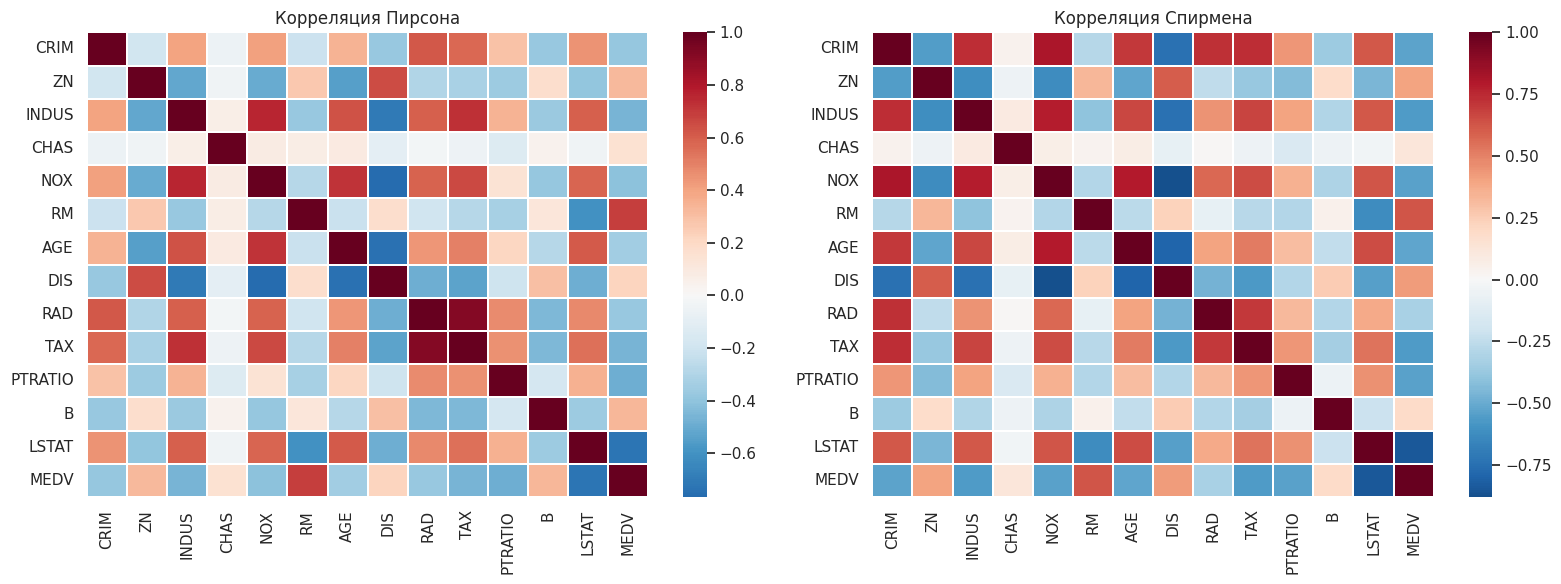

In [3]:
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if "RAD" in num_cols and "_rad_zone" not in df_clean.columns:
    pass

corr_p = df_clean[num_cols].corr(method="pearson")
corr_s = df_clean[num_cols].corr(method="spearman")

print("Pearson corr с MEDV (по модулю убывание):\n")
print(corr_p["MEDV"].drop("MEDV").abs().sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr_p, ax=axes[0], annot=False, cmap="RdBu_r", center=0, linewidths=0.2)
axes[0].set_title("Корреляция Пирсона")

sns.heatmap(corr_s, ax=axes[1], annot=False, cmap="RdBu_r", center=0, linewidths=0.2)
axes[1].set_title("Корреляция Спирмена")

plt.tight_layout()
plt.show()


## 4. Требование ИУ5-65Б: **парные диаграммы** (`pairplot`)

Подмножество признаков: сильнее всего связанные с **`MEDV`** и смежные показатели. Оттенок (`hue`) — зона доступности дорог (**`_rad_zone`**). Если график слишком тяжёлый, можно уменьшить число столбцов.


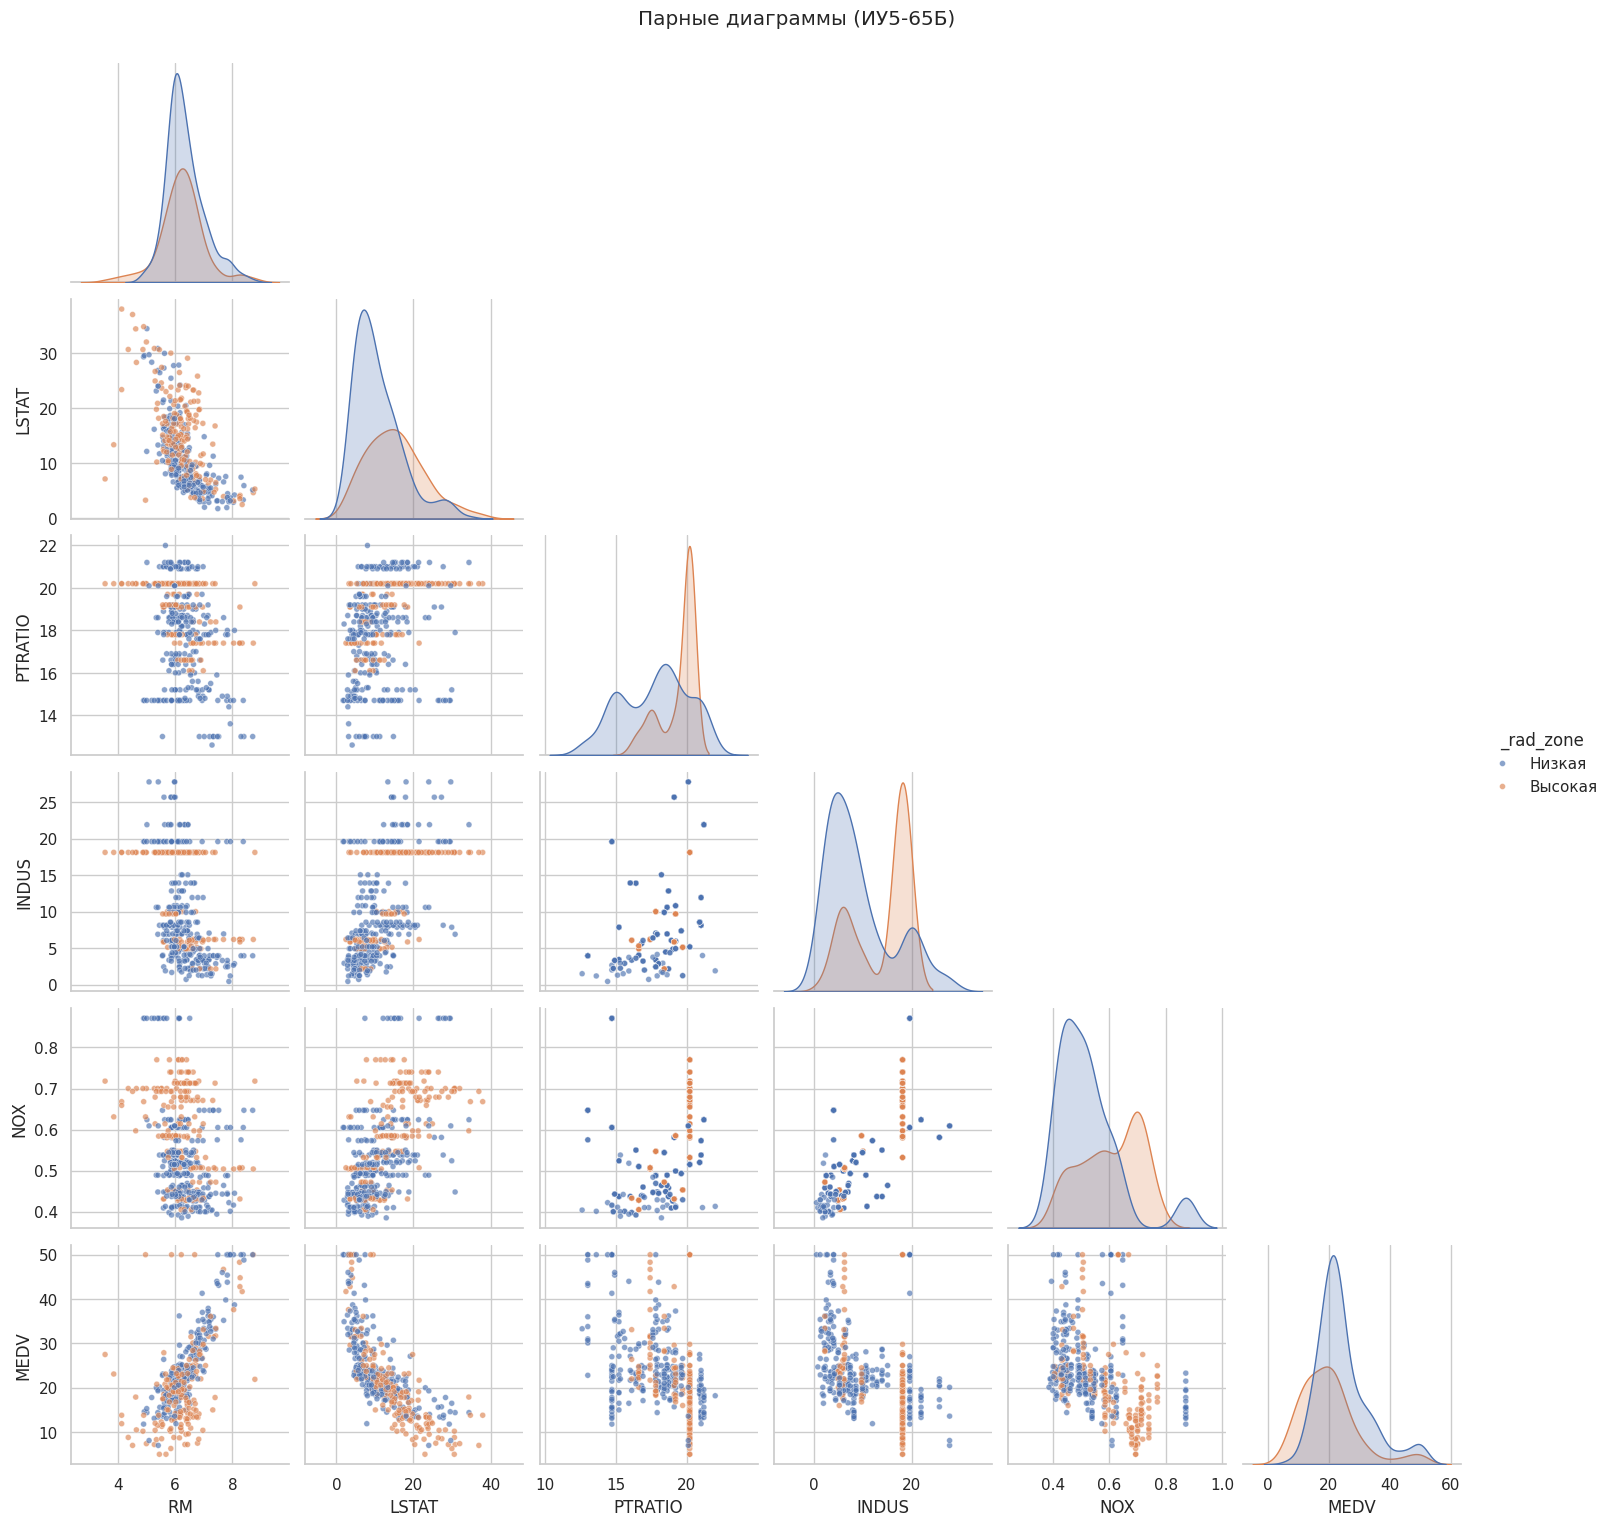

In [4]:
# Несколько главных признаков + MEDV для читаемости
cands = [
    "RM", "LSTAT", "PTRATIO", "INDUS", "NOX", "DIS", "TAX",
    "AGE", "CRIM", "RAD", "MEDV",
]

pair_cols = [c for c in cands if c in df_clean.columns]
cols_pair = []
for c in ["RM", "LSTAT", "PTRATIO", "INDUS", "NOX", "MEDV"]:
    if c in pair_cols:
        cols_pair.append(c)

sub = df_clean[cols_pair + (["_rad_zone"] if "_rad_zone" in df_clean.columns else [])].copy()

hue_col = "_rad_zone" if "_rad_zone" in sub.columns else None

g = sns.pairplot(sub, hue=hue_col, corner=True, plot_kws=dict(alpha=0.65, s=18))
g.figure.suptitle("Парные диаграммы (ИУ5-65Б)", y=1.02)
plt.show()


## 5. Выводы для задачи 1 (по **нашему** датасету Boston Housing после запуска ноутбука)

*Ниже числа соответствуют цепочке: загрузка CSV → стандартизация имён столбцов → искусственные пропуски в `AGE` и `RM` (6%, `random_state=8`) → удаление **строк** с `NaN`.*

### Объём данных и пропуски
- Исходно **506** наблюдений, после очистки от пропусков **448** (**58** строк удалено, доля ~11,5%).
- Для реальной задачи рациональнее было бы **заполнять** пропуски (медиана/модель по соседям), здесь удаление строк — осознанный выбор по формулировке РК «удалите строки или столбцы»; для модели машинного обучения объём **448** объектов всё ещё достаточен для простых моделей регрессии.

### Связь признаков с целевой **MEDV** (стоимость / медиана цены домов в $1000)

**Коэффициент Пирсона** (линейная связь), по убыванию |r|:
| Признак | r с MEDV | Интерпретация кратко |
|---------|----------|-------------------------|
| **LSTAT** | **−0,73** | доля населения с «низким статусом» — главный из линейных предикторов; чем выше LSTAT, тем ниже MEDV. |
| **RM** | **+0,69** | среднее число комнат — сильная **положительная** связь с ценой. |
| **PTRATIO** | −0,49 | ученик на учителя — чем выше, тем ниже MEDV. |
| **INDUS**, **TAX** | −0,47 каждый | индустриальный уклад и налог связаны с более низкими ценами в этом срезе. |

**Спирмен** (монотонная связь) подчёркивает **LSTAT**: **−0,85** — нелинейная монотонная зависимость сильнее, чем «чистая» линейная; у **RM** Спирмен **+0,63** слабее Пирсона, что намекает на отклонения от линейности или влияние выбросов.

### Многоколлинеарность между признаками (без MEDV)
Сильные пары (Пирсон):
- **TAX ↔ RAD**: **r ≈ 0,91** — почти линейно избыточная информация; в линейной регрессии не стоит одновременно оставлять оба без регуляризации/отбора.
- **NOX ↔ INDUS**, **NOX ↔ DIS**, **INDUS ↔ TAX**, **AGE ↔ DIS**: |r| > 0,72 — возможны нестабильные оценки коэффициентов при OLS.

### Возможность построения моделей ML
1. **Линейные модели** (Ridge / Lasso / Elastic Net) уместны: есть выраженные линейные связи с **MEDV**, но из‑за **многоколлинарности** лучше **регуляризация или понижение размерности**, а не «голый» МНК.
2. **Дерева и ансамбли** (Random Forest, градиентный бустинг) хорошо переносят нелинейности и совместную зависимость признаков; по pairplot связь **RM–MEDV** и **LSTAT–MEDV** может быть **криволинейной** — деревья её обычно ловят.
3. Отдельно стоит смотреть на **CHAS** (бинарный) и сегменты **`_rad_zone`** на pairplot: при построении модели их можно учитывать как категориальные / взаимодействия с **DIS**, **RAD**.

### Вклад признаков (по корреляциям, до обучения модели)
- **Наибольший вклад в прогноз MEDV по линейной корреляции ожидать от LSTAT и RM**; затем PTRATIO, INDUS, TAX, NOX, CRIM (все отрицательны кроме RM среди топа).
- **RAD** как отдельный числовой признак имеет среднюю связь с MEDV (**r ≈ −0,37**), но связан почти функционально с **TAX** — вклад нужно трактовать с осторожностью совместно с налоговой ставкой и зонированием.

*Итог:* датасет **пригоден для обучения регрессии** после очистки; ключевые кандидаты в признак — **LSTAT**, **RM**; для устойчивой линейной модели из-за RAD–TAX и NOX–INDUS рекомендованы **регуляризация или отбор признаков**; нелинейные методы дополнительно оправданы сильной спирменовской связью **LSTAT** с **MEDV**.
